# Impact of Steel Tariffs on Employment
### A Difference-in-Differences Analysis

This notebook estimates the causal effect of U.S. steel tariffs on employment in the steel industry using a Difference-in-Differences (DiD) framework.

We compare employment trends between:
- **Treated industry**: Iron and Steel Mills (NAICS 331110)
- **Control industry**: Nonferrous Metal Die-Casting (NAICS 331523)

The goal is to isolate the impact of tariff policy from general economic trends.

In [11]:
# Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

## Data

We use QCEW data aggregated to the state-industry-year level.

The dataset includes:
- Employment levels
- NAICS Industry classification
- Geographic identifiers (state)
- Year

In [12]:

# Yearly Files
files = ["2015.q1-q4.singlefile.csv",
    "2016.q1-q4.singlefile.csv",
    "2017.q1-q4.singlefile.csv",
    "2018.q1-q4.singlefile.csv",
    "2019.q1-q4.singlefile.csv"]

NAICS_TREAT = "331110" # Treated Industry
NAICS_CTRL = "331523"  # Control Industry

naics_keep = {NAICS_TREAT, NAICS_CTRL}
qtrs_keep = {2, 3, 4}

keep_parts = []

for f in files:

    # we just need a few columns

    df = pd.read_csv(f,
        usecols=[
            "area_fips", "industry_code", "year", "qtr",
            "month1_emplvl", "month2_emplvl", "month3_emplvl"],
        dtype={"area_fips": "string", "industry_code": "string"},
        low_memory=False)

    df["area_fips"] = df["area_fips"].str.strip()
    df["industry_code"] = df["industry_code"].str.strip()

    # filter for just treated and control industry

    df = df[df["qtr"].isin(qtrs_keep) & df["industry_code"].isin(naics_keep)] 

    condition = df["area_fips"].str.fullmatch(r"\d{2}000", na=False)
    df = df[condition]

    # create average yearly employment variable

    df["avg_emplvl"] = (
        df["month1_emplvl"] + df["month2_emplvl"] + df["month3_emplvl"]) / 3

    keep_parts.append(df)

# concatenate all files
qcew = pd.concat(keep_parts, ignore_index=True)
print("\nTotal quarterly rows kept:", len(qcew))




Total quarterly rows kept: 1242


## Key Variables

- `treated`: 1 if steel industry, 0 otherwise  
- `post`: 1 for post-tariff period (2019+), 0 otherwise  
- `log_emp`: log of employment  

The interaction `treated × post` captures the causal effect.

In [18]:
# additional transformation

 # treatment indicator (treated or control industry)

qcew["treated"] = (qcew["industry_code"] == NAICS_TREAT).astype(int)

 # grouped observations

annual = qcew.groupby(["area_fips", "industry_code", "year", "treated"],
    as_index=False)["avg_emplvl"].mean()

 # time indicator (before or after the tariffs)

annual["post"] = (annual["year"] >= 2019).astype(int)

 # employment cleaning and log
 
annual = annual[annual["avg_emplvl"] > 0].copy()
annual["log_emp"] = np.log(annual["avg_emplvl"])

# as integers

annual["year"] = annual["year"].astype(int)
annual["treated"] = annual["treated"].astype(int)
annual["post"] = annual["post"].astype(int)


annual.to_csv("steel_employment_annual.csv", index=False)
print("Final annual rows:", len(annual))
print(annual.head())

Final annual rows: 291
  area_fips industry_code  year  treated   avg_emplvl  post   log_emp
0     01000        331110  2015        1  5405.000000     0  8.595080
1     01000        331110  2016        1  4963.333333     0  8.509833
2     01000        331110  2017        1  4819.444444     0  8.480414
3     01000        331110  2018        1  4973.222222     0  8.511823
4     01000        331110  2019        1  5033.666667     1  8.523904


## Model Specification

We estimate the following Difference-in-Differences (DiD) specification:

$$
\log(emp_{it}) = \beta_0 + \beta_1 (treated_i \times post_t) + \alpha_i + \gamma_t + \epsilon_{it}
$$

Where:
- $\alpha_i$: state fixed effects  
- $\gamma_t$: year fixed effects  

The coefficient of interest is $\beta_1$, which captures the causal effect of tariffs on employment in the treated industry.

In [19]:
# model

ols = smf.ols("log_emp ~ treated*post + C(area_fips) + C(year)",
    data=annual).fit(cov_type="cluster", cov_kwds={"groups": annual["area_fips"]})

# helper functions

def coef_to_pct(beta):
    return np.exp(beta) - 1

def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""

#  main DiD coefficient

b = ols.params["treated:post"]
se = ols.bse["treated:post"]
p = ols.pvalues["treated:post"]
lo, hi = ols.conf_int().loc["treated:post"].tolist()

pct = coef_to_pct(b) * 100
pct_lo = coef_to_pct(lo) * 100
pct_hi = coef_to_pct(hi) * 100


# main table for paper

main_table = pd.DataFrame({"Variable": ["Treated × Post",
        "Implied effect (%)",
        "State FE",
        "Year FE",
        "Observations"],
    "Coefficient": [
        f"{b:.4f}{stars(p)} ({se:.4f})",
        f"{pct:.2f}\\%",
        "Yes",
        "Yes",
        f"{int(ols.nobs)}"]})

print('main table:', main_table)

# regression table

full_table = pd.DataFrame({"Variable": ols.params.index,
    "Coefficient": ols.params.values,
    "Std. Error": ols.bse.values,
    "P-value": ols.pvalues.values})

full_table["Coefficient"] = full_table["Coefficient"].round(4)
full_table["Std. Error"] = full_table["Std. Error"].round(4)
full_table["P-value"] = full_table["P-value"].round(4)

full_table.to_csv('full_employment_regression_table')
print('full regression table: ', full_table)


main table:              Variable        Coefficient
0      Treated × Post  0.1594** (0.0753)
1  Implied effect (%)            17.28\%
2            State FE                Yes
3             Year FE                Yes
4        Observations                291
full regression table:                   Variable  Coefficient  Std. Error  P-value
0               Intercept       6.8065      0.1575   0.0000
1   C(area_fips)[T.04000]      -2.2980      0.1630   0.0000
2   C(area_fips)[T.05000]       0.2923      0.0000   0.0000
3   C(area_fips)[T.06000]       0.2114      0.0000   0.0000
4   C(area_fips)[T.08000]      -2.1808      0.1630   0.0000
5   C(area_fips)[T.10000]      -4.3010      0.1786   0.0000
6   C(area_fips)[T.11000]      -5.7801      0.1786   0.0000
7   C(area_fips)[T.12000]      -1.8713      0.0000   0.0000
8   C(area_fips)[T.13000]      -1.1700      0.1106   0.0000
9   C(area_fips)[T.17000]       0.8333      0.0000   0.0000
10  C(area_fips)[T.18000]       1.5530      0.0000   0.000

## Interpretation

The coefficient on the interaction term **treated × post** is positive and statistically significant (β = 0.159, p < 0.10), indicating that employment in the steel industry increased following the introduction of tariffs relative to the control industry.

Because the dependent variable is in logarithms, this coefficient can be interpreted as a percentage change. Converting the estimate, the results suggest that steel tariffs are associated with an approximate **17.3% increase in employment** in the treated industry compared to the control group.

However, this result should be interpreted with caution. The validity of the Difference-in-Differences framework relies on the parallel trends assumption, and any deviation from this could bias the estimated effect.

## Visualization

Below we visualize the estimated trends.

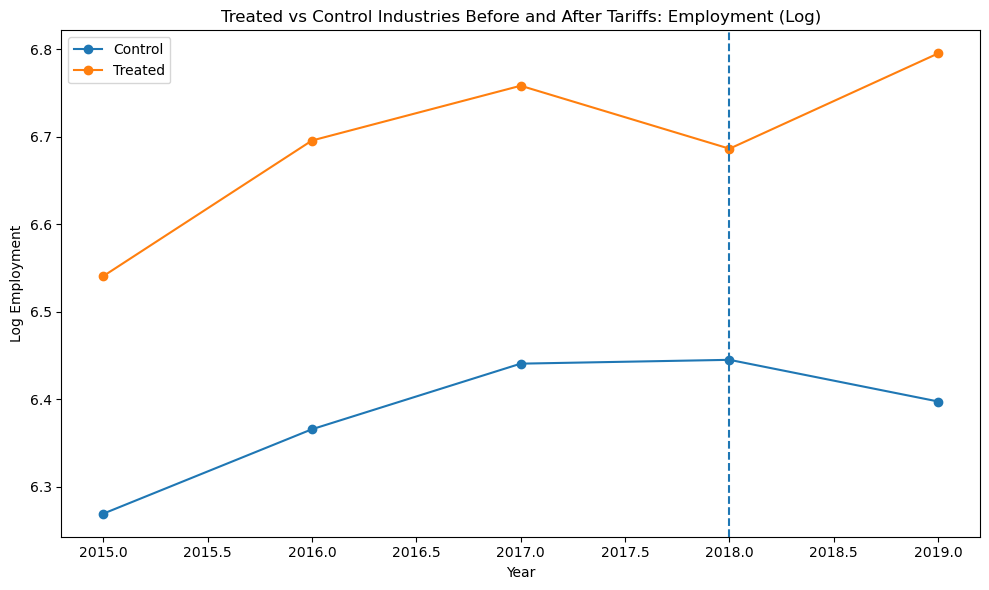

In [15]:
avg = (annual.groupby(["year", "treated"])["log_emp"]
       .mean().reset_index())

plt.figure(figsize=(10,6))

for t, label in zip([0,1], ["Control", "Treated"]):
    subset = avg[avg["treated"] == t]
    plt.plot(subset["year"], subset["log_emp"], marker="o", label=label)

plt.axvline(2018, linestyle="--")  # tariff year
plt.title("Treated vs Control Industries Before and After Tariffs: Employment (Log)")
plt.xlabel("Year")
plt.ylabel("Log Employment")
plt.legend()
plt.tight_layout()
plt.savefig("employment_trends.png", dpi=300)
plt.show()